In [14]:
# import os
# import sys
# sys.path.insert(0, r"C:\Users\Andre\PycharmProjects\CODA_HE_nucleus_segmentation\Analysis\separate_cells_manual_annotations")
# from separate_cells_manual_annotations.write_features_functions import *
# from separate_cells_manual_annotations.util import *
# from separate_cells_manual_annotations.manual_annotations_functions import *

In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import h5py  # For reading MATLAB v7.3 files

In [2]:
# Define the list of radii to study
radii = [16, 32, 48, 64, 80, 96, 112, 128]

# Define the base path for the data
outpth = r'\\169.254.138.20\Andre\data\Stardist\Healthy nPOD\mat files AF AK\volvolcell_classes'

# Define the output path for the composition analysis
outpthmat_comp = os.path.join(outpth, 'composition_analysis')
os.makedirs(outpthmat_comp, exist_ok=True)

# Define cell types and mapping
celltypes = ["islets", "ducts", "vessels", "fat", "acini", "stroma", "noise", "nerves", "immune", "cell_type"]
cell_type_mapping = {
    1.0: "islets",
    2.0: "ducts",
    3.0: "vessels",
    4.0: "fat",
    5.0: "acini",
    6.0: "stroma",
    7.0: "noise",
    8.0: "nerves",
    9.0: "immune"
}

# Define the colors for each cell type (RGB values in [0, 255])
class_colors = [
    [70, 220, 220],   # 1 islets of Langerhans
    [80, 70, 220],    # 2 pancreatic ducts
    [70, 180, 80],    # 3 blood vessels
    [220, 220, 80],   # 4 fat
    [130, 50, 190],   # 5 acini
    [240, 180, 230],  # 6 stroma
    [255, 255, 255],  # 7 background (noise)
    [160, 130, 40],   # 8 nerves
    [0, 0, 0]         # 9 immune cells
]

# Normalize the colors to the range [0, 1]
class_colors = np.array(class_colors) / 255

# Create a dictionary to map cell types to their corresponding colors
cell_type_colors = {
    "islets": class_colors[0],
    "ducts": class_colors[1],
    "vessels": class_colors[2],
    "fat": class_colors[3],
    "acini": class_colors[4],
    "stroma": class_colors[5],
    "noise": class_colors[6],
    "nerves": class_colors[7],
    "immune": class_colors[8]
}



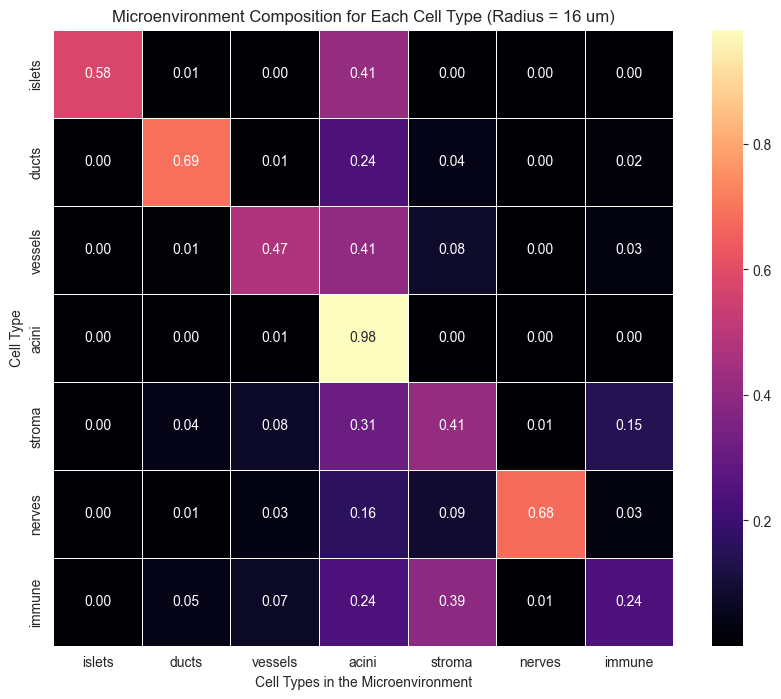

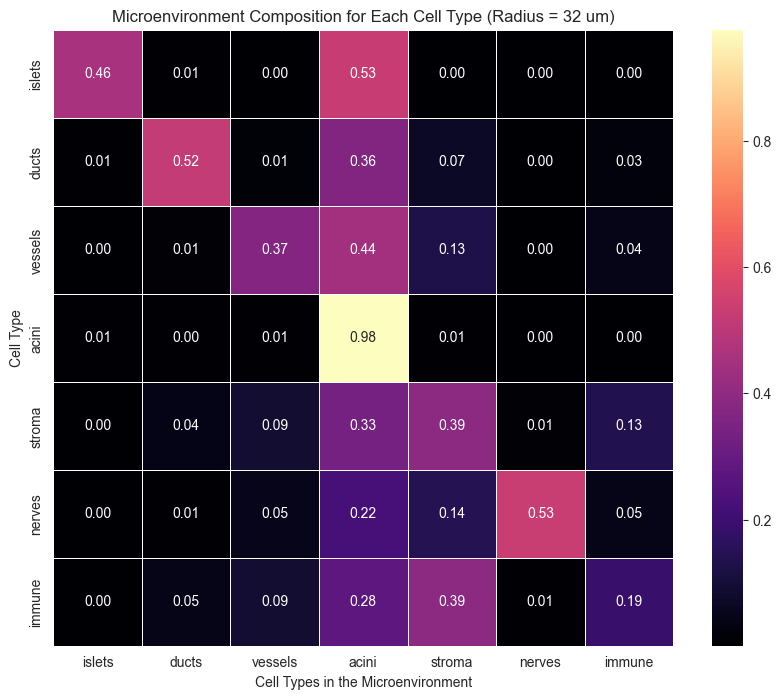

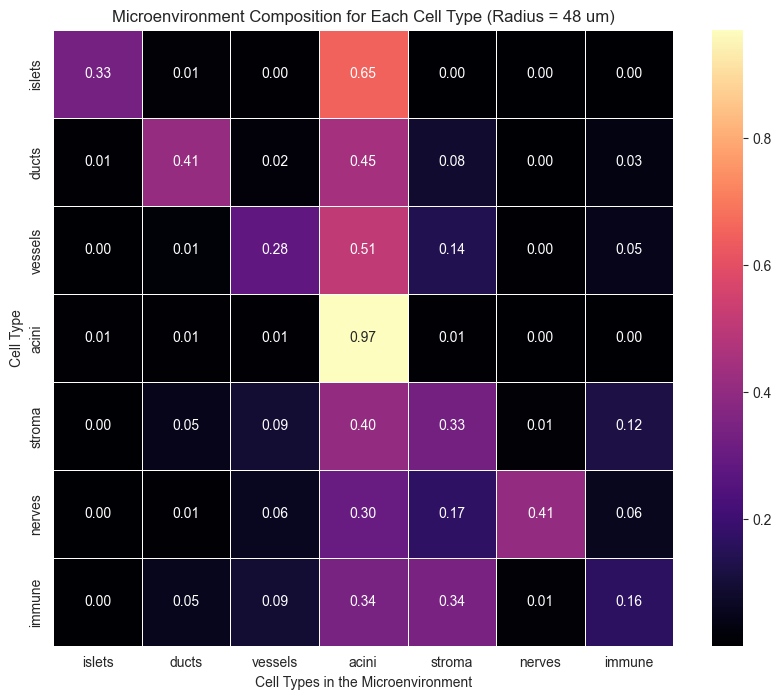

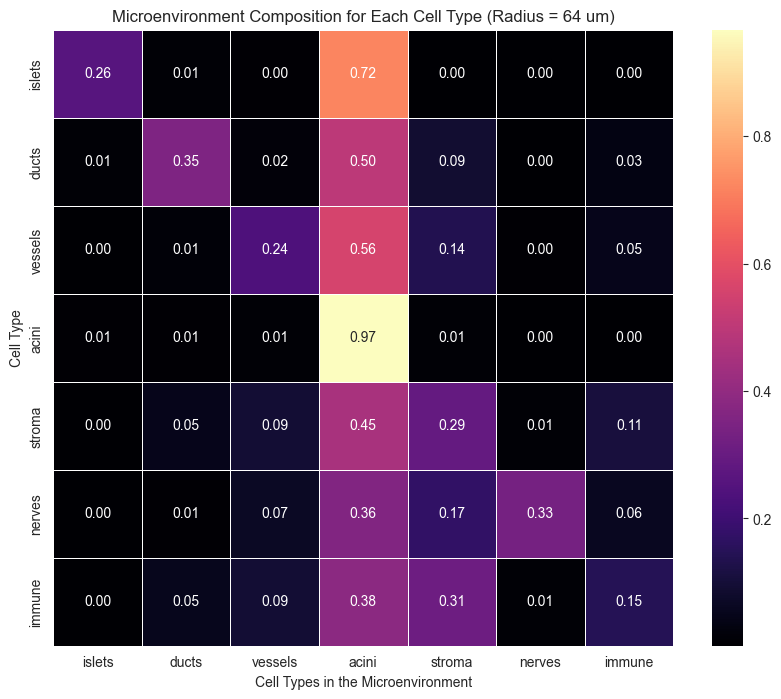

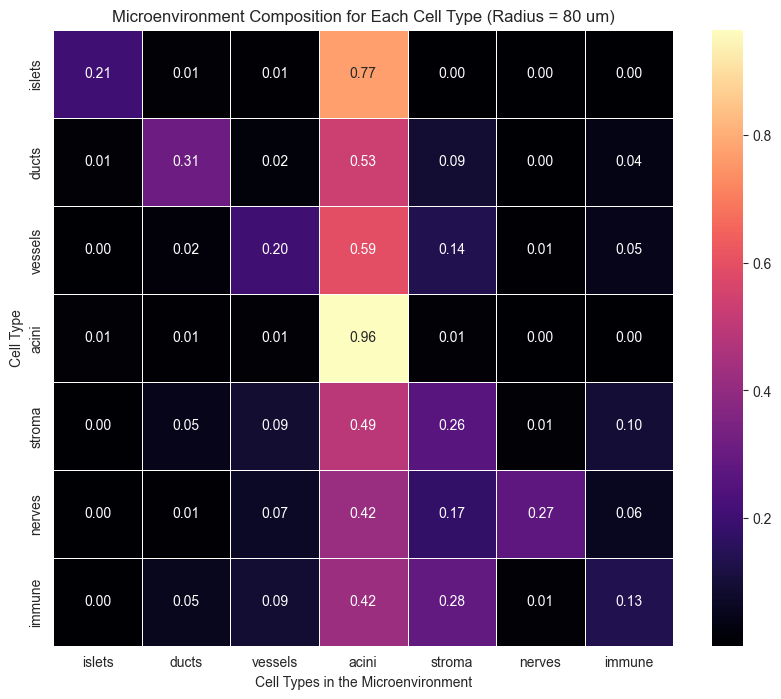

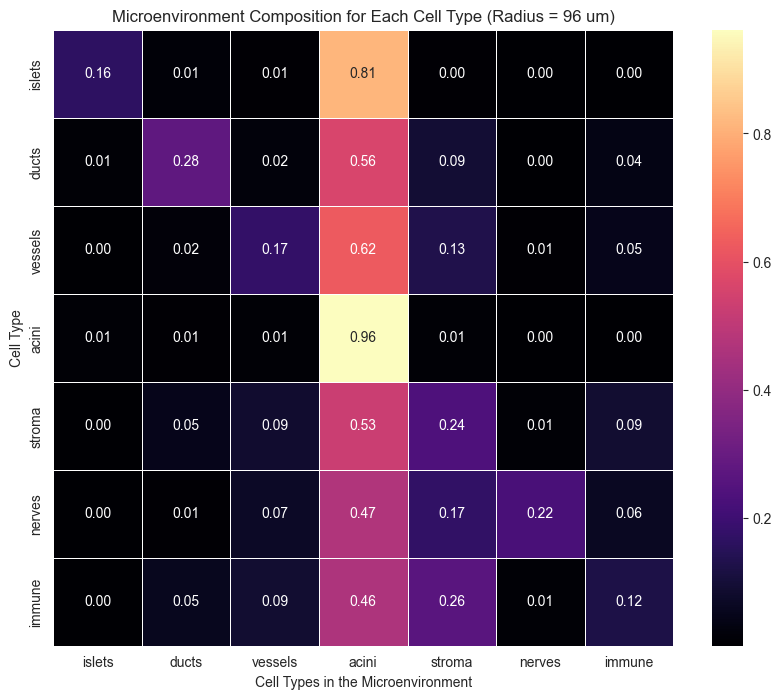

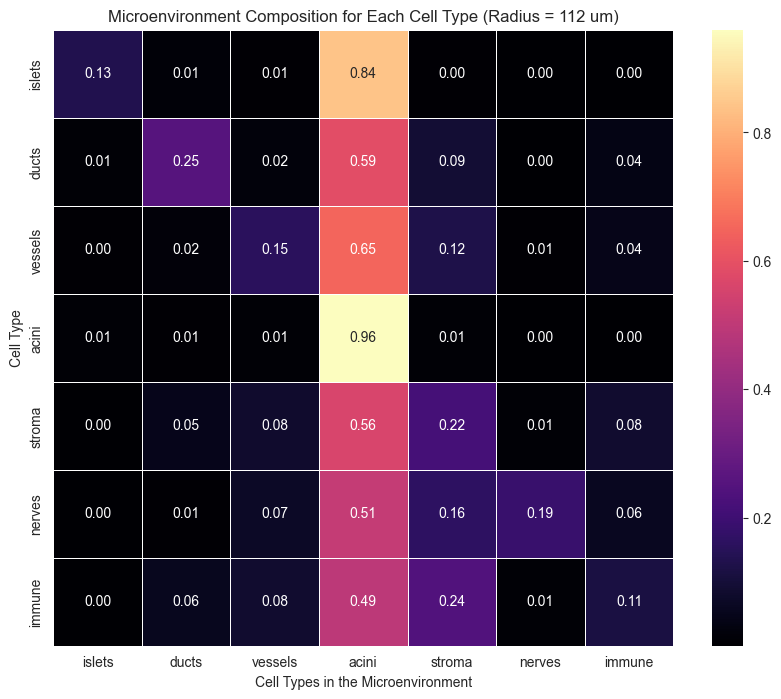

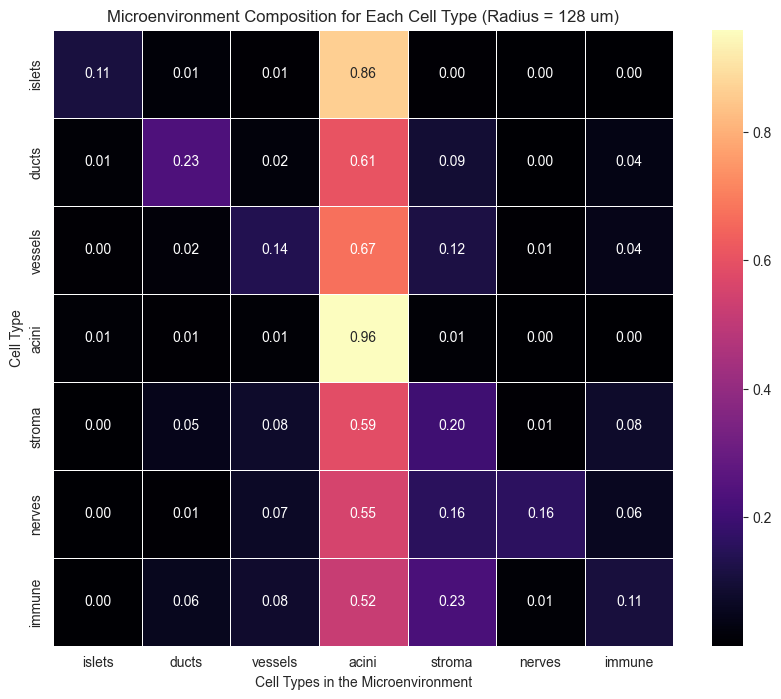

In [3]:
# Initialize a dictionary to store microenvironment compositions for each radius
microenvironment_compositions = {}

# Loop over each radius
for radius in radii:
    # Construct the file path for the current radius
    pth = os.path.join(outpth, f'nondiabetic_12152024_HE_ds8_stardist_col_volcell_classes_immune_cell_microenvironment_{radius}_um.mat')

    # Read the mat file
    f = h5py.File(pth, 'r')
    data = f['bigtable']
    data = np.array(data)
    data = data.T
    data = pd.DataFrame(data, columns=celltypes)

    # Define the numeric value corresponding to "noise"
    noise_value = 7  # Since "noise" is the 7th column and cell_type starts at 1

    # Remove rows where cell_type is the noise value
    data = data[data["cell_type"] != noise_value]

    # Exclude the "noise" column (if it exists)
    if "noise" in data.columns:
        data = data.drop(columns=["noise"])

    # Remove rows where cell_type is "fat" (4.0)
    data = data[data["cell_type"] != 4.0]

    # Drop the "fat" column
    if "fat" in data.columns:
        data = data.drop(columns=["fat"])

    # Normalize the data (convert counts to proportions)
    data_normalized = data.iloc[:, :-1].div(data.iloc[:, :-1].sum(axis=1), axis=0)

    # Add the "cell_type" column back to the normalized data
    data_normalized["cell_type"] = data["cell_type"]

    # Drop any rows with NaN values
    data_normalized_cleaned = data_normalized.dropna()

    # Group the data by cell_type and calculate the mean composition of the microenvironment
    microenvironment_composition = data_normalized_cleaned.groupby("cell_type").mean()

    # Replace the numeric cell_type values with their names
    microenvironment_composition.index = microenvironment_composition.index.map(cell_type_mapping)

    # Store the microenvironment composition in the dictionary
    microenvironment_compositions[radius] = microenvironment_composition

    # Visualize the microenvironment composition as a heatmap for the current radius
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        microenvironment_composition,
        annot=True,  # Annotate the cells with the values
        cmap="magma",  # Choose a color map
        fmt=".2f",  # Format the annotations to 2 decimal places
        linewidths=0.5,
    )
    plt.title(f"Microenvironment Composition for Each Cell Type (Radius = {radius} um)")
    plt.xlabel("Cell Types in the Microenvironment")
    plt.ylabel("Cell Type")
    plt.savefig(os.path.join(outpthmat_comp, f'microenvironment_composition_heatmap_{radius}_um.svg'), bbox_inches="tight", dpi=300)
    # plt.close()  # Close the plot to free up memory

In [23]:
# Create a DataFrame to store the composition data for all radii and cell types
composition_data = pd.DataFrame()

# Loop through each radius and cell type to collect the data
for radius in radii:
    for cell_type in cell_type_mapping.values():
        if cell_type == "fat" or cell_type == "noise":
            continue  # Skip "fat" and "noise" as they were removed earlier

        # Get the composition for the current cell type and radius
        composition = microenvironment_compositions[radius].loc[cell_type]

        # Add the data to the DataFrame
        for microenvironment_cell_type, value in composition.items():
            composition_data = pd.concat([composition_data, pd.DataFrame({
                "Radius": [radius],
                "Cell Type": [cell_type],
                "Microenvironment Cell Type": [microenvironment_cell_type],
                "Composition": [value * 100]  # Convert composition to percentage
            })])

# Reset the index of the DataFrame
composition_data.reset_index(drop=True, inplace=True)

In [24]:
# Set Seaborn theme and custom parameters
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

# Create a separate plot for each cell type
for cell_type in cell_type_mapping.values():
    if cell_type == "fat" or cell_type == "noise":
        continue  # Skip "fat" and "noise" as they were removed earlier

    # Filter the data for the current cell type
    cell_type_data = composition_data[composition_data["Cell Type"] == cell_type]

    # Create a new plot
    plt.figure(figsize=(10, 6))

    # Use seaborn to plot each microenvironment cell type as a separate line
    sns.lineplot(
        data=cell_type_data,
        x="Radius",
        y="Composition",
        hue="Microenvironment Cell Type",
        palette=cell_type_colors,
        linewidth=2.5,
    )

    # Customize the plot
    plt.title(f"Change in Microenvironment Composition for {cell_type} with Increasing Radius")
    plt.xlabel("Radius (um)")
    plt.ylabel("Composition (%)")  # Update y-axis label to indicate percentage
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Place legend outside the plot
    plt.grid(False)  # Remove grid lines
    plt.tight_layout()

    # Save the plot
    plt.savefig(os.path.join(outpthmat_comp, f'change_in_microenvironment_composition_{cell_type}.svg'), bbox_inches="tight", dpi=300)
    plt.close()  # Close the plot to free up memory

_base.py (949): When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
_base.py (949): When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
_base.py (949): When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
_base.py (949): When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
_base.py (949): When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
_base.py (

In [25]:
outpthmat_comp

'\\\\169.254.138.20\\Andre\\data\\Stardist\\Healthy nPOD\\mat files AF AK\\volvolcell_classes\\composition_analysis'